In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv('data/process/loan_data_cleaned.csv')
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,3.200000e+06,2.491667e+06
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,4.100000e+06,1.525000e+06
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,2.275000e+06,1.485000e+06
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,2.050000e+06,3.837500e+06
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,1.633333e+06,1.210000e+06
5,6,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,33900000,2.812500,2.511111,4.800000e+06,1.350000e+06
6,7,5,1,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,1,70800000,3.793103,2.145455,1.450000e+06,8.250000e+06
7,8,2,1,1,5700000,15000000,20,382,13200000,5700000,11800000,6000000,0,36700000,2.631579,2.446667,1.900000e+06,7.500000e+05
8,9,0,1,1,800000,2200000,20,782,1300000,800000,2800000,600000,1,5500000,2.750000,2.500000,8.000000e+05,1.100000e+05
9,10,5,0,0,1100000,4300000,10,388,3200000,1400000,3300000,1600000,0,9500000,3.909091,2.209302,1.833333e+05,4.300000e+05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 4269 non-null   int64  
 3   self_employed             4269 non-null   int64  
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   int64  
 9   commercial_assets_value   4269 non-null   int64  
 10  luxury_assets_value       4269 non-null   int64  
 11  bank_asset_value          4269 non-null   int64  
 12  loan_status               4269 non-null   int64  
 13  total_assets_value        4269 non-null   int64  
 14  loan_to_

In [4]:
df.describe()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
count,4269.000000,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160,3.254877e+07,2.984807,2.231797,2.055050e+06,2.194899e+06
std,1232.498479,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904,1.950656e+07,0.595496,0.643145,2.003233e+06,2.597537e+06
min,1.000000,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000,4.000000e+05,1.500000,0.750000,3.333333e+04,1.500000e+04
25%,1068.000000,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000,1.630000e+07,2.464286,1.767347,7.750000e+05,7.000000e+05
50%,2135.000000,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000,3.150000e+07,3.000000,2.142857,1.450000e+06,1.357143e+06
75%,3202.000000,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000,4.720000e+07,3.500000,2.616216,2.500000e+06,2.516667e+06
max,4269.000000,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000,9.070000e+07,4.000000,5.666667,9.900000e+06,1.935000e+07


In [6]:
corr_matrix = df.corr()

In [7]:
corr_matrix

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
loan_id,1.000000,0.005326,0.015536,0.001745,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765,0.017685,0.012555,-0.011235,0.007186,0.010837,-0.005401
no_of_dependents,0.005326,1.000000,0.002697,0.000765,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,-0.018114,0.005289,-0.029256,0.020927,-0.627381,0.010627
education,0.015536,0.002697,1.000000,-0.023224,0.011625,0.010631,-0.008417,-0.004649,0.010930,-0.006763,0.012471,0.009424,0.004918,0.009513,-0.004923,0.004820,0.010318,0.020108
self_employed,0.001745,0.000765,-0.023224,1.000000,0.002368,0.001450,0.004107,-0.004866,0.006144,-0.017998,0.004413,-0.000215,0.000345,0.000023,-0.004078,0.003889,-0.005566,-0.004513
income_annum,0.012592,0.007266,0.011625,0.002368,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,-0.015189,0.931845,0.019714,0.016068,0.568127,0.467731
loan_amount,0.008170,-0.003366,0.010631,0.001450,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,0.016150,0.867067,0.340791,-0.210844,0.530610,0.500970
loan_term,0.009809,-0.020111,-0.008417,0.004107,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,-0.113036,0.010131,-0.002876,-0.017829,0.025654,-0.592993
cibil_score,0.016323,-0.009998,-0.004649,-0.004866,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,0.770518,-0.023433,0.002980,-0.003459,-0.008477,-0.019369
residential_assets_value,0.020936,0.007376,0.010930,0.006144,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,-0.014367,0.790402,0.021176,0.319579,0.351763,0.284969
commercial_assets_value,0.018595,-0.001531,-0.006763,-0.017998,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,0.008246,0.730576,0.029573,0.209195,0.372467,0.303705


# **Heatmap** 

In [8]:
sns.set_theme(style="darkgrid", palette="pastel")

In [9]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

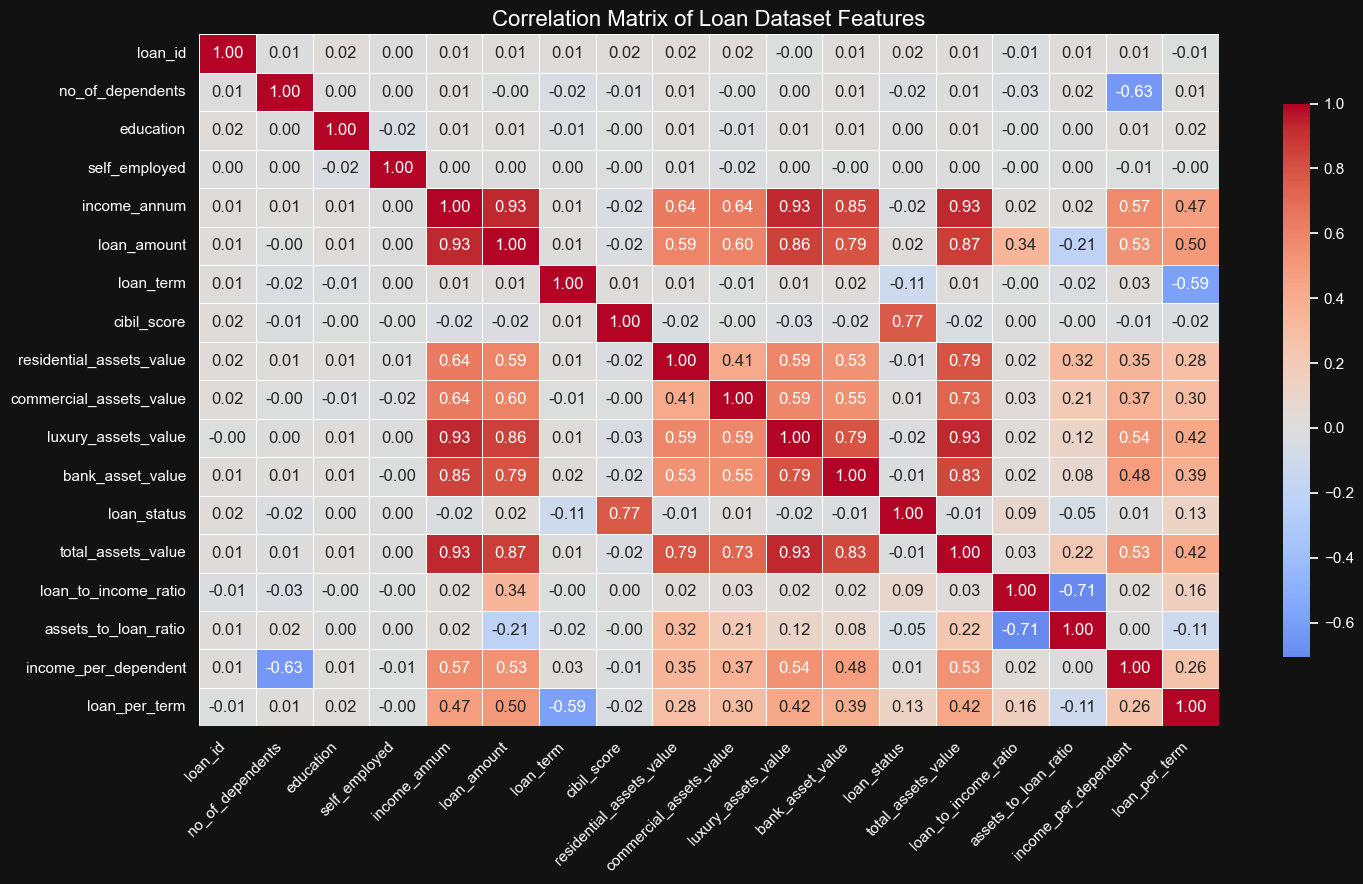

In [11]:
plt.figure(figsize=(15,9))

# 3. Generate a custom heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation coefficients on the plot
    fmt=".2f",           # Format to 2 decimal places
    cmap='coolwarm',     # Color map from blue (negative) to red (positive)
    center=0,            # Set the middle value of the colormap to 0
    linewidths=0.5,      # Add lines between cells for better visibility
    cbar_kws={"shrink": .8} # Adjust the size of the color bar
)

# 4. Finalize plot details
plt.title('Correlation Matrix of Loan Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlapping
plt.tight_layout()

# 5. Display the plot
plt.show()

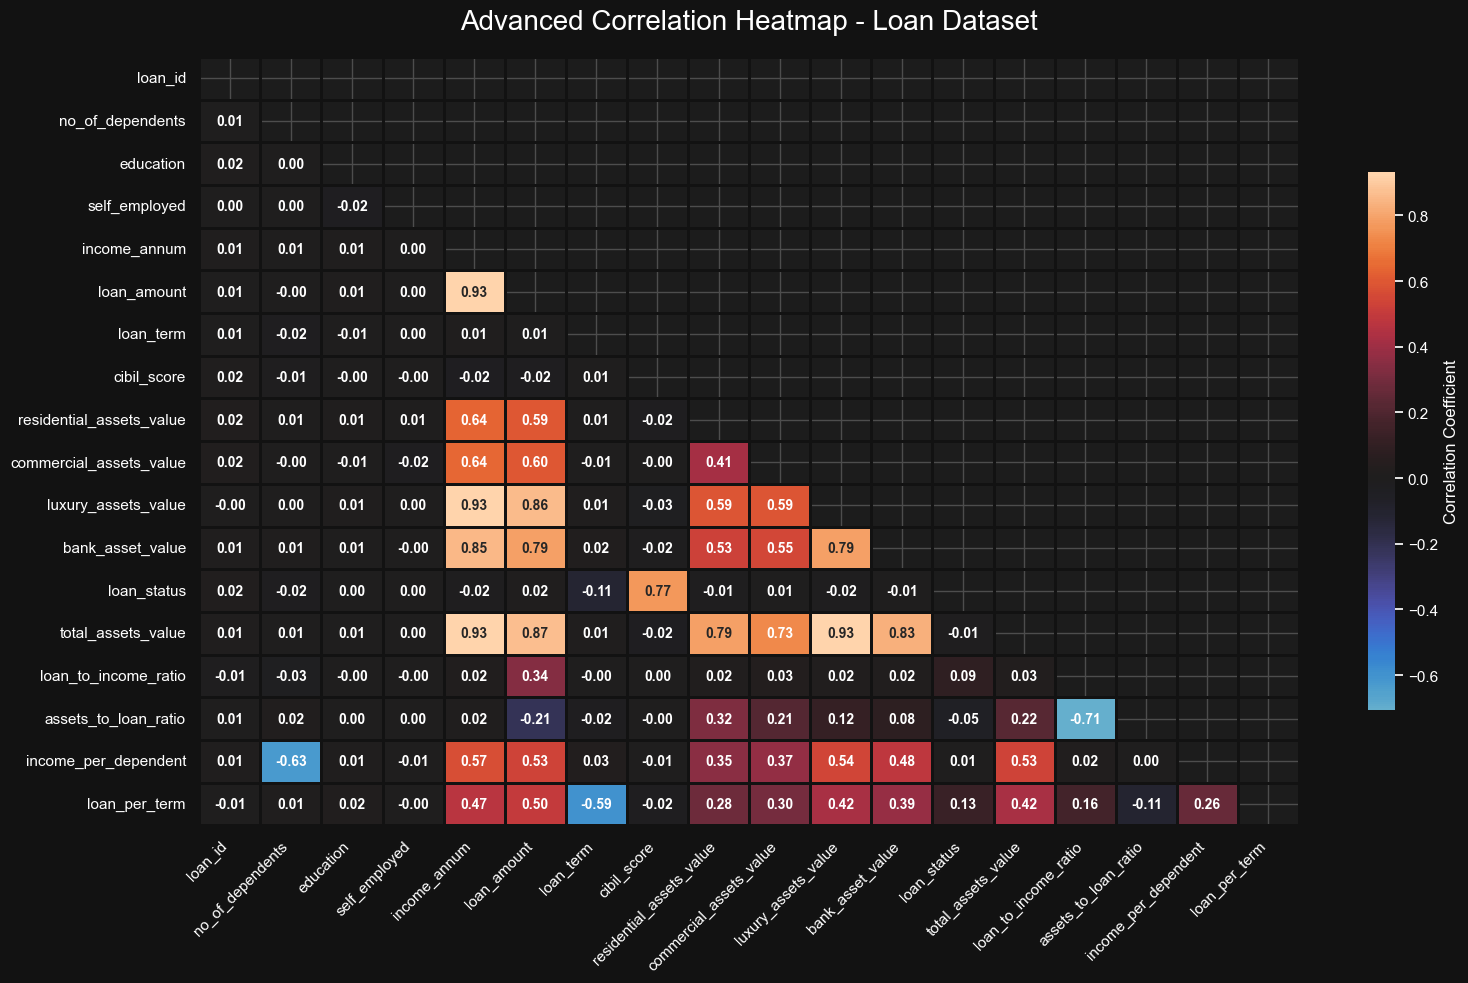

In [12]:
# 2. Tạo Mask (Mặt nạ) để ẩn đi một nửa ma trận (phần đối xứng)
# Điều này giúp biểu đồ thoáng hơn và tránh lặp lại thông tin
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Khởi tạo figure
plt.figure(figsize=(16, 10))

# 4. Vẽ Heatmap với các cải tiến thẩm mỹ
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Apply mask to hide the upper triangle
    annot=True,              # Show correlation coefficients
    fmt=".2f",               # Format to 2 decimal places
    cmap='icefire',          # 'icefire' or 'mako' look stunning on dark backgrounds
    center=0,                # Set center to 0
    linewidths=1,            # Increase linewidth for a "grid" look
    linecolor='#121212',     # Match line color with background
    cbar_kws={"shrink": .7, "label": "Correlation Coefficient"}, # Add label to color bar
    annot_kws={"size": 10, "weight": "bold"} # Make annotations bolder and clearer
)

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title('Advanced Correlation Heatmap - Loan Dataset', fontsize=20, pad=20, color='white')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Loại bỏ viền trắng thừa xung quanh
plt.tight_layout()

# 6. Hiển thị
plt.show()

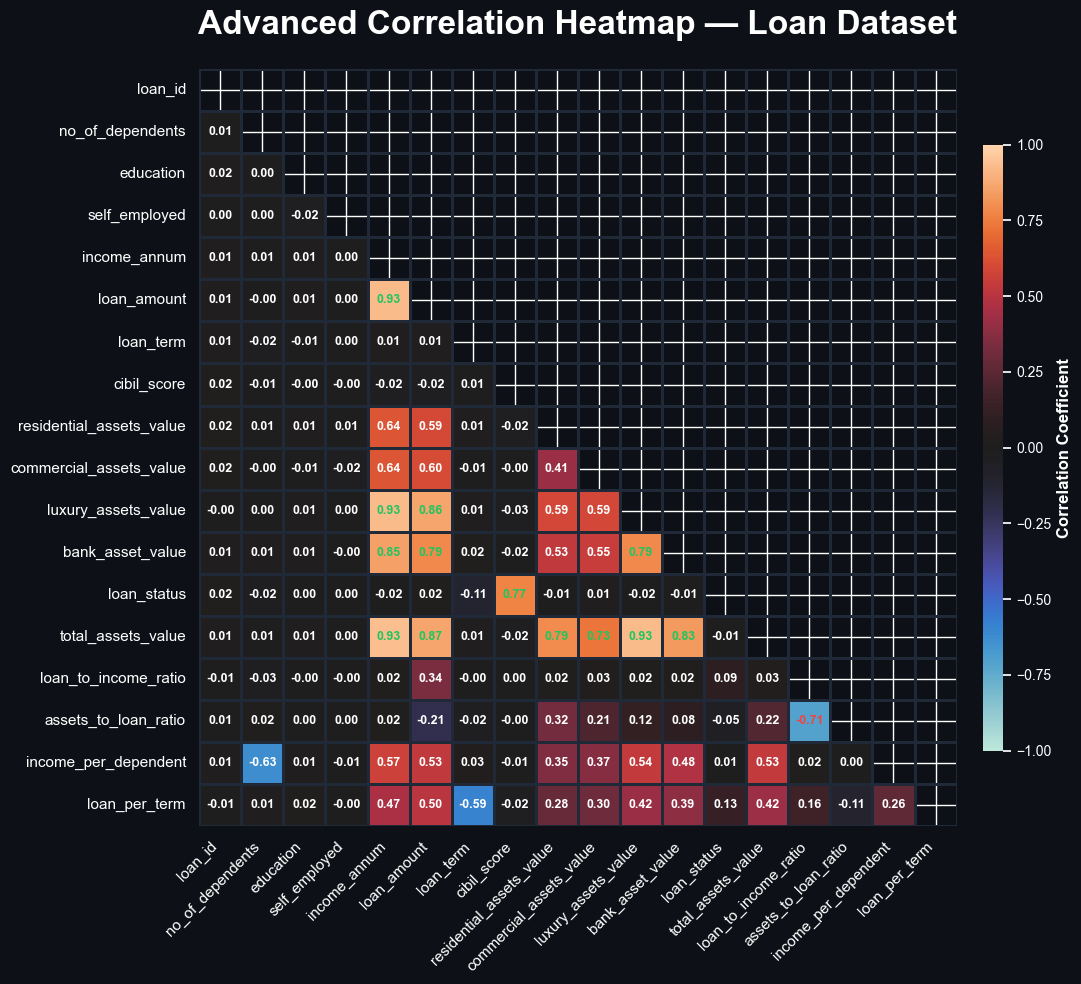

In [23]:


# ==============================
# STYLE CONFIG
# ==============================
plt.style.use("dark_background")

# ==============================
# CREATE CORRELATION MATRIX
# ==============================
corr_matrix = df.corr(numeric_only=True)

# ==============================
# CREATE MASK (Hide Upper Triangle)
# ==============================
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# ==============================
# CREATE FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(14, 10))

# Background colors
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# ==============================
# HEATMAP
# ==============================
heatmap = sns.heatmap(
    corr_matrix,
    
    mask=mask,

    annot=True,
    fmt=".2f",

    cmap=sns.color_palette("icefire", as_cmap=True),

    vmin=-1,
    vmax=1,
    center=0,

    square=True,

    linewidths=0.8,
    linecolor='#1f2937',

    annot_kws={
        "size": 9,
        "weight": "bold",
        "color": "white"
    },

    cbar_kws={
        "shrink": 0.8,
        "aspect": 30,
        "pad": 0.02,
        "label": "Correlation Coefficient"
    },

    ax=ax
)

# ==============================
# COLORBAR CUSTOMIZATION
# ==============================
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(colors='white', labelsize=10)

cbar.set_label(
    "Correlation Coefficient",
    color='white',
    fontsize=12,
    weight='bold'
)

# ==============================
# TITLES & LABELS
# ==============================
ax.set_title(
    "Advanced Correlation Heatmap — Loan Dataset",
    fontsize=24,
    weight='bold',
    color='white',
    pad=25
)

# X-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=11,
    color='white'
)

# Y-axis labels
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11,
    color='white'
)

# ==============================
# REMOVE SPINES
# ==============================
for spine in ax.spines.values():
    spine.set_visible(False)

# ==============================
# OPTIONAL: Highlight Strong Correlations
# ==============================
for text in ax.texts:
    try:
        value = float(text.get_text())

        # Strong positive correlation
        if value >= 0.7:
            text.set_color('#22c55e')

        # Strong negative correlation
        elif value <= -0.7:
            text.set_color('#ef4444')

        # Weak correlation
        else:
            text.set_color('white')

    except:
        pass

# ==============================
# LAYOUT
# ==============================
plt.tight_layout()

# ==============================
# SHOW
# ==============================
plt.show()

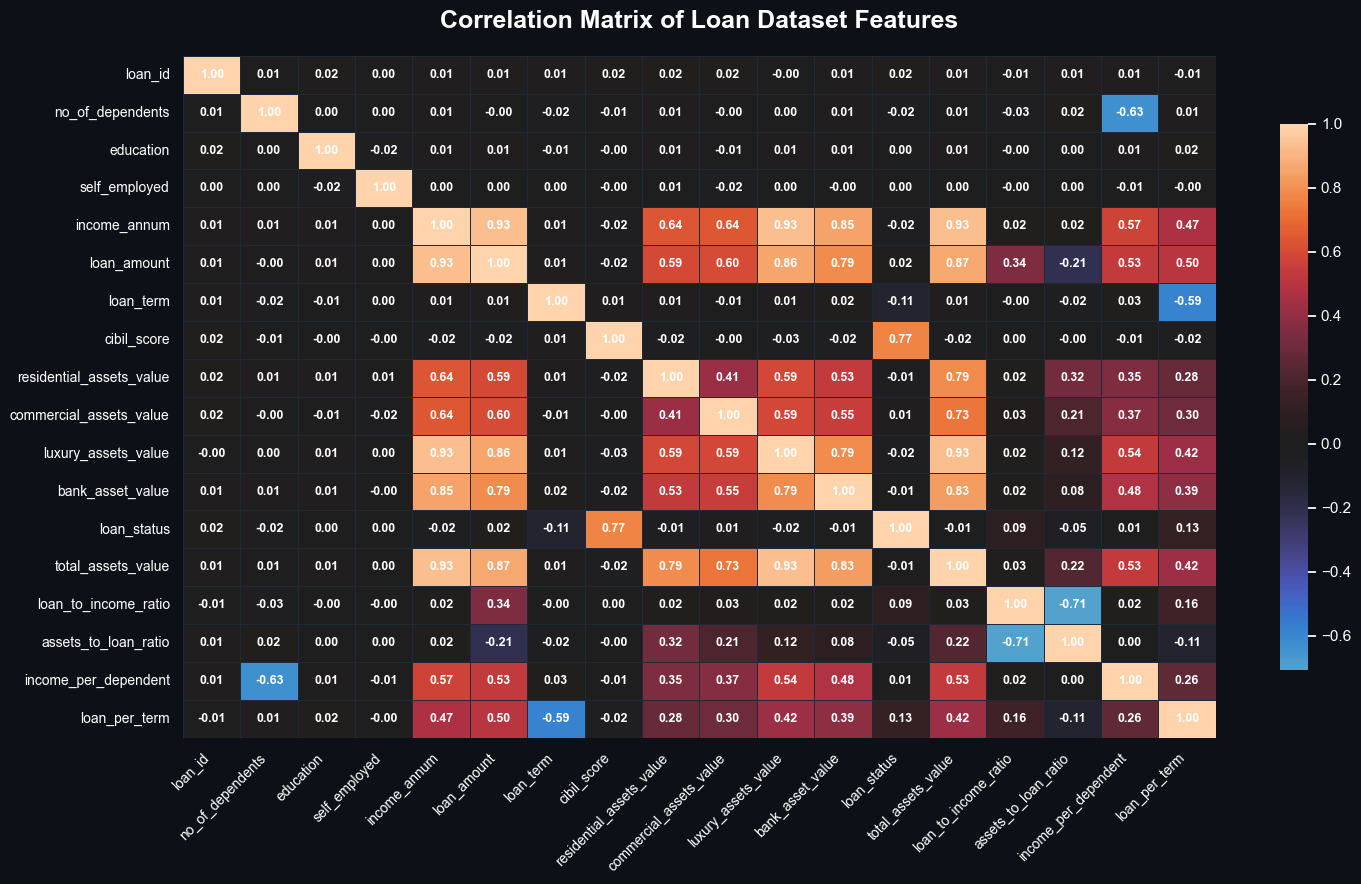

In [16]:
# ==============================
# DARK THEME STYLE
# ==============================
plt.style.use("dark_background")

# ==============================
# CREATE FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(15, 9))

# Background color
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# ==============================
# HEATMAP
# ==============================
heatmap = sns.heatmap(
    corr_matrix,

    annot=True,
    fmt=".2f",

    cmap='icefire',      # Better for dark theme
    center=0,

    linewidths=0.5,
    linecolor='#1f2937',

    cbar_kws={
        "shrink": 0.8
    },

    annot_kws={
        "color": "white",
        "fontsize": 9,
        "weight": "bold"
    }
)

# ==============================
# COLORBAR CUSTOMIZATION
# ==============================
cbar = heatmap.collections[0].colorbar

cbar.ax.yaxis.set_tick_params(color='white')

plt.setp(
    plt.getp(cbar.ax.axes, 'yticklabels'),
    color='white'
)

# ==============================
# TITLES & LABELS
# ==============================
plt.title(
    'Correlation Matrix of Loan Dataset Features',
    fontsize=18,
    weight='bold',
    color='white',
    pad=20
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10,
    color='white'
)

plt.yticks(
    fontsize=10,
    color='white'
)

# ==============================
# REMOVE SPINES
# ==============================
for spine in ax.spines.values():
    spine.set_visible(False)

# ==============================
# LAYOUT
# ==============================
plt.tight_layout()

# ==============================
# SHOW
# ==============================
plt.show()

# **Train models**

In [24]:
# drop unused column
df.drop("loan_id", axis=1, inplace=True)

In [25]:
# split features 
X = df.drop("loan_status", axis=1)

# target
y = df["loan_status"]

In [26]:
X.shape

(4269, 16)

In [27]:
y.shape

(4269,)

In [28]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# numeric features 
numeric_features = X.columns

In [30]:
# preprocessor
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

In [31]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])

## **Baseline model Logistic Regression**

In [32]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [33]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

### Predictions

In [34]:
y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

y_train_prob = baseline_pipeline.predict_proba(X_train)[:, 1]
y_test_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

### Train metrics

In [35]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
train_loss = log_loss(y_train, y_train_prob)

### Test metrics

In [36]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)
test_loss = log_loss(y_test, y_test_prob)

### Results

In [37]:
print("=" * 60)
print("BASELINE MODEL - LOGISTIC REGRESSION")
print("=" * 60)

print("\nTRAIN METRICS")
print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"F1 Score  : {train_f1:.4f}")
print(f"ROC AUC   : {train_auc:.4f}")
print(f"Log Loss  : {train_loss:.4f}")

print("\nTEST METRICS")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC AUC   : {test_auc:.4f}")
print(f"Log Loss  : {test_loss:.4f}")

BASELINE MODEL - LOGISTIC REGRESSION

TRAIN METRICS
Accuracy  : 0.9280
Precision : 0.9400
Recall    : 0.9445
F1 Score  : 0.9423
ROC AUC   : 0.9723
Log Loss  : 0.2075

TEST METRICS
Accuracy  : 0.9251
Precision : 0.9332
Recall    : 0.9473
F1 Score  : 0.9402
ROC AUC   : 0.9789
Log Loss  : 0.1833


### **Classification report**

In [64]:
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       323
           1       0.93      0.95      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.93      0.92       854



### **Confusion matrix**

In [66]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

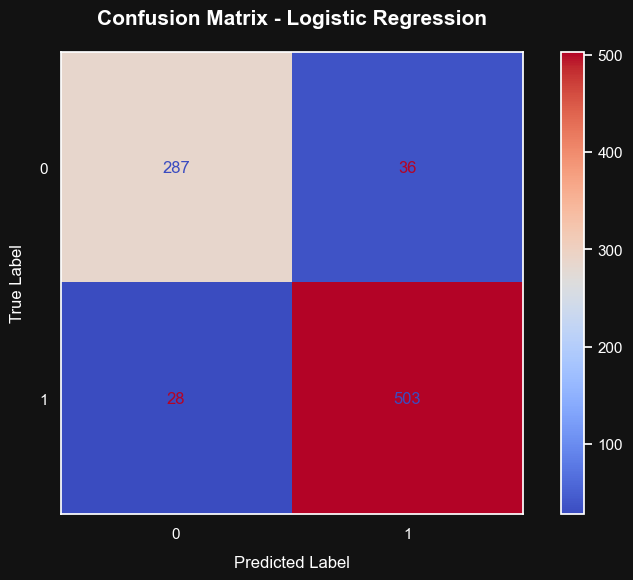

In [72]:

fig, ax = plt.subplots(figsize=(10, 6))

# Tùy chỉnh: 
# - cmap="magma" hoặc "viridis" thường hợp với nền tối hơn là "Blues"
# - ax=ax để áp dụng các thiết lập rcParams vào đúng khung hình
disp.plot(cmap="coolwarm", ax=ax, values_format='d')

# 4. CẢI TIẾN QUAN TRỌNG: Loại bỏ lưới đè lên các ô màu
ax.grid(False) 

# Tùy chỉnh tiêu đề và nhãn
plt.title("Confusion Matrix - Logistic Regression", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)

plt.show()

In [73]:
from sklearn.model_selection import cross_val_score

In [74]:
# CROSS VALIDATION
cv_scores = cross_val_score(
    baseline_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCROSS VALIDATION")
print(f"CV Scores : {cv_scores}")
print(f"Mean CV Accuracy : {cv_scores.mean():.4f}")


CROSS VALIDATION
CV Scores : [0.94028103 0.92154567 0.92388759 0.92622951 0.92614302]
Mean CV Accuracy : 0.9276


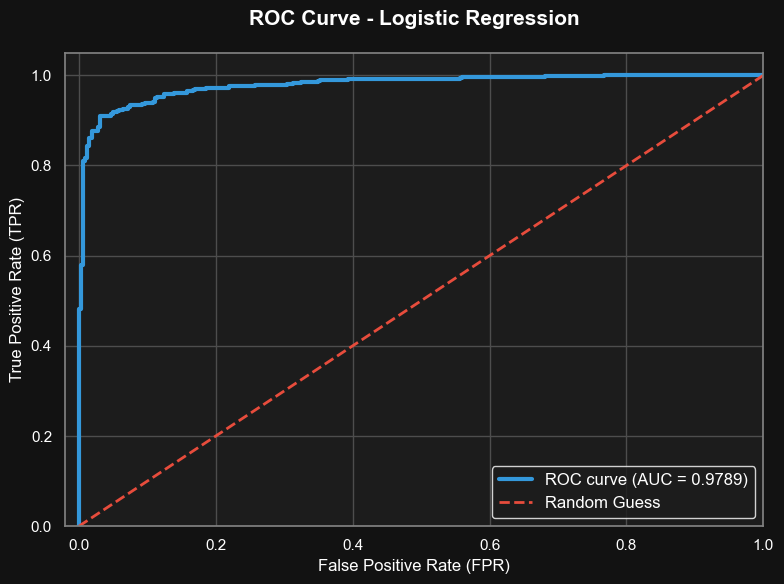

In [78]:
from sklearn.metrics import roc_curve


y_probs = baseline_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 2. Thiết lập giao diện tối
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "0.5"
})

plt.figure(figsize=(8, 6))

# 3. Vẽ đường ROC
plt.plot(fpr, tpr, color='#3498db', lw=3, label=f'ROC curve (AUC = {auc_score:.4f})')

# 4. Vẽ đường chéo cơ sở (Random Guess)
plt.plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Random Guess')

# 5. Tinh chỉnh thẩm mỹ
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=15, pad=20, fontweight='bold')

# Đặt Legend vào trong biểu đồ vì diện tích đường ROC thường trống ở góc dưới bên phải
plt.legend(loc="lower right", facecolor='#1c1c1c', edgecolor='white', fontsize=12)

plt.tight_layout()
plt.show()


### Visualization

In [51]:
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

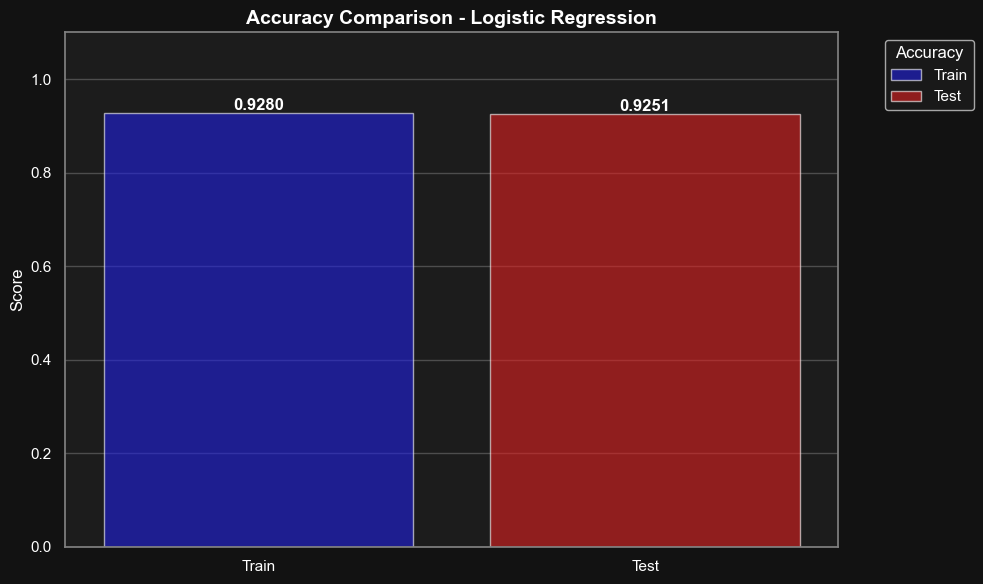

In [83]:
labels = ['Train', 'Test']
values = [train_accuracy, test_accuracy]

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=labels, y=values, hue=labels, palette=['blue', 'red'], legend=True, alpha=0.6)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.legend(title='Accuracy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Accuracy Comparison - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.tight_layout()

plt.show()


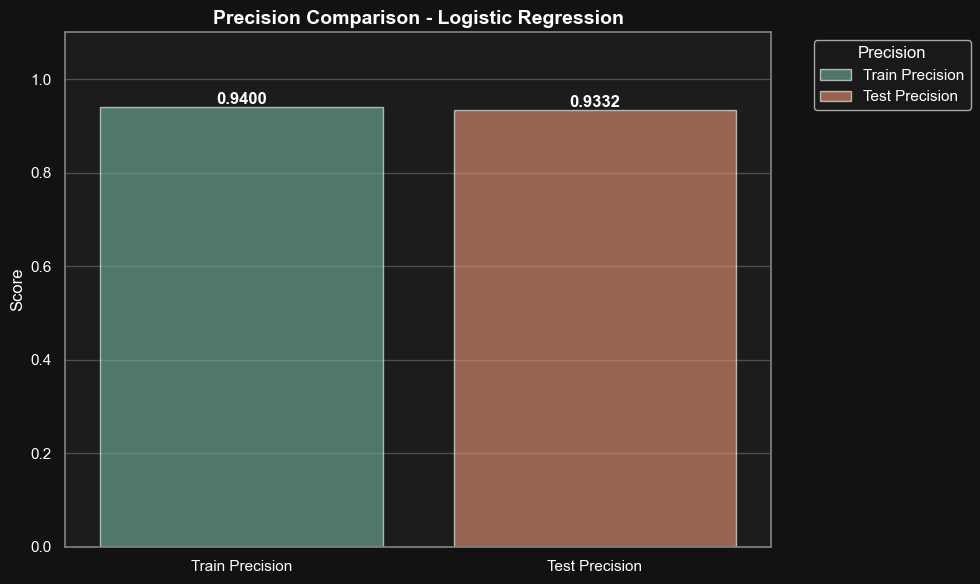

In [ ]:
labels = ['Train Precision', 'Test Precision']
values = [train_precision, test_precision]

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=labels, y=values, hue=labels, palette='Set2', legend=True, alpha=0.6)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.legend(title='Precision', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Precision Comparison - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.tight_layout()

plt.show()

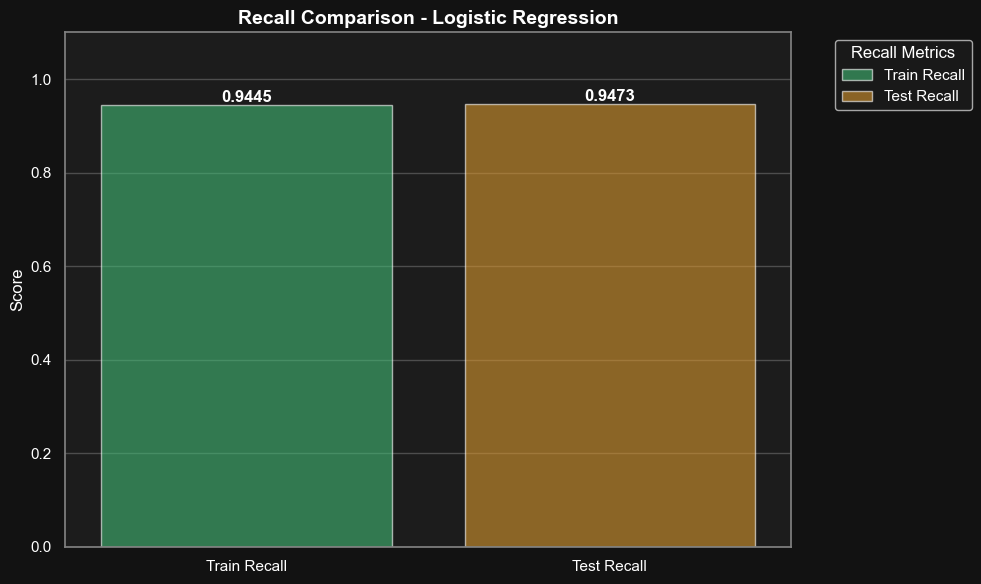

In [85]:
labels = ['Train Recall', 'Test Recall']
values = [train_recall, test_recall]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=labels, 
    y=values, 
    hue=labels, 
    palette=['#2ecc71', '#f39c12'], 
    legend=True, 
    alpha=0.6,
    edgecolor='white'
)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

# Đưa Legend ra ngoài
plt.legend(title='Recall Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tiêu đề và nhãn trục
plt.title('Recall Comparison - Logistic Regression', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Score', color='white')
plt.ylim(0, 1.1)
plt.tight_layout()

plt.show()


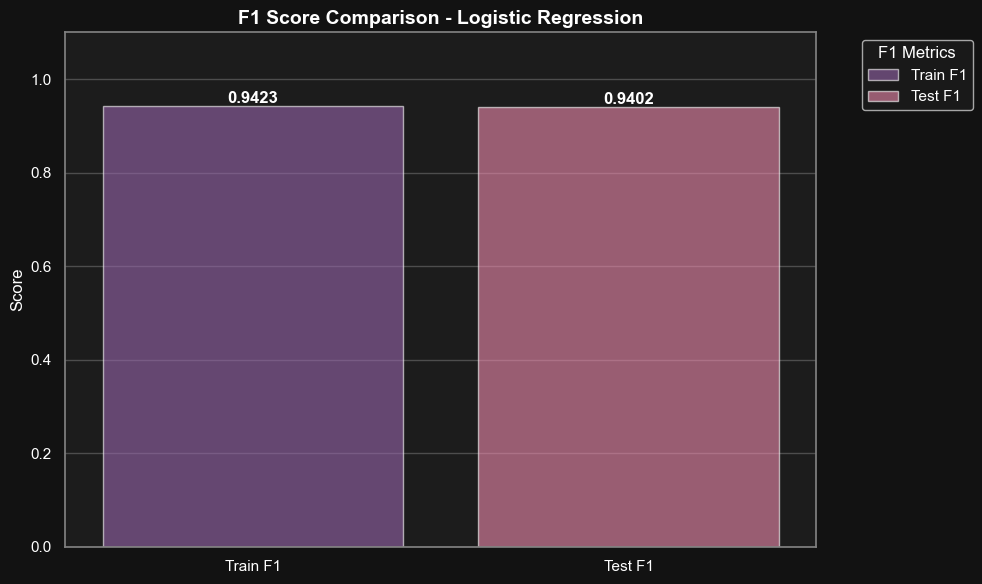

In [86]:
labels = ['Train F1', 'Test F1']
values = [train_f1, test_f1]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=labels, 
    y=values, 
    hue=labels, 
    palette=['#9b59b6', '#fd79a8'], 
    legend=True, 
    alpha=0.6,
    edgecolor='white'
)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

# Tùy chỉnh Legend và nhãn
plt.legend(title='F1 Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('F1 Score Comparison - Logistic Regression', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Score', color='white')
plt.ylim(0, 1.1)
plt.tight_layout()

plt.show()

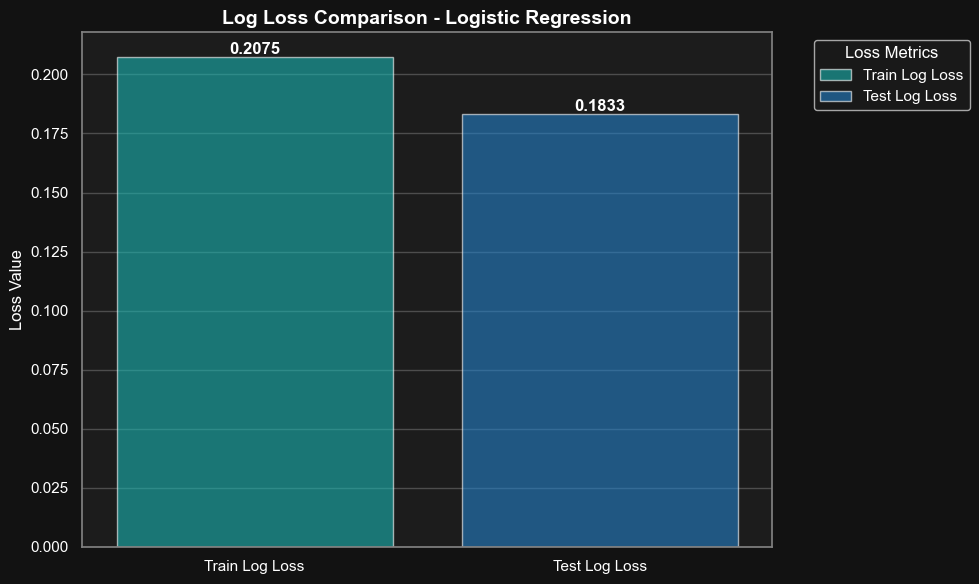

In [87]:
labels = ['Train Log Loss', 'Test Log Loss']
values = [train_loss, test_loss]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=labels, 
    y=values, 
    hue=labels, 
    palette=['#00cec9', '#0984e3'], 
    legend=True, 
    alpha=0.6,
    edgecolor='white'
)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

plt.legend(title='Loss Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Log Loss Comparison - Logistic Regression', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Loss Value', color='white')


plt.tight_layout()
plt.show()

### **Save and Load model**

#### Save model 

In [93]:
import joblib

In [92]:
feature_columns = X.columns.tolist()

In [94]:
joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)

['models/feature_columns.pkl']

In [95]:
joblib.dump(
    baseline_pipeline,
    "models/logistic_regression_baseline.pkl"
)

print("Baseline model saved!")

Baseline model saved!


#### Load model 

In [96]:
baseline_model = joblib.load(
    "models/logistic_regression_baseline.pkl"
)

In [97]:
# Load feature order
feature_columns = joblib.load(
    "models/feature_columns.pkl"
)

#### Test

In [98]:
# Sample input
sample_data = {
    "no_of_dependents": 2,
    "education": 1,
    "self_employed": 0,
    "income_annum": 500000,
    "loan_amount": 200000,
    "loan_term": 10,
    "cibil_score": 750,
    "residential_assets_value": 300000,
    "commercial_assets_value": 100000,
    "luxury_assets_value": 50000,
    "bank_asset_value": 200000,
    "total_assets_value": 650000,
    "loan_to_income_ratio": 0.4,
    "assets_to_loan_ratio": 3.25,
    "income_per_dependent": 166666,
    "loan_per_term": 20000
}

In [99]:
# Convert to DataFrame
input_df = pd.DataFrame([sample_data])

# Ensure correct column order
input_df = input_df[feature_columns]

# Predict
prediction = baseline_model.predict(input_df)[0]

# Probability
probability = baseline_model.predict_proba(input_df)[0][1]

print("Prediction:", prediction)
print("Approval Probability:", probability)

Prediction: 1
Approval Probability: 0.9442152385849304


## **Random Forest**

In [103]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [104]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

In [105]:
# train predictions 
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_prob = rf_pipeline.predict_proba(X_train)[:, 1]

In [106]:
# test predictions
rf_test_pred = rf_pipeline.predict(X_test)
rf_test_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [107]:
# train metrics 
rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)

rf_train_precision = precision_score(
    y_train,
    rf_train_pred
)

rf_train_recall = recall_score(
    y_train,
    rf_train_pred
)

rf_train_f1 = f1_score(
    y_train,
    rf_train_pred
)

rf_train_auc = roc_auc_score(
    y_train,
    rf_train_prob
)

rf_train_loss = log_loss(
    y_train,
    rf_train_prob
)

In [108]:
# test metrics
rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_test_precision = precision_score(
    y_test,
    rf_test_pred
)

rf_test_recall = recall_score(
    y_test,
    rf_test_pred
)

rf_test_f1 = f1_score(
    y_test,
    rf_test_pred
)

rf_test_auc = roc_auc_score(
    y_test,
    rf_test_prob
)

rf_test_loss = log_loss(
    y_test,
    rf_test_prob
)

In [109]:
# results 
print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

# ---------------- TRAIN ----------------

print("\nTRAIN METRICS")

print(f"Accuracy  : {rf_train_accuracy:.4f}")
print(f"Precision : {rf_train_precision:.4f}")
print(f"Recall    : {rf_train_recall:.4f}")
print(f"F1 Score  : {rf_train_f1:.4f}")
print(f"ROC AUC   : {rf_train_auc:.4f}")
print(f"Log Loss  : {rf_train_loss:.4f}")

# ---------------- TEST ----------------

print("\nTEST METRICS")

print(f"Accuracy  : {rf_test_accuracy:.4f}")
print(f"Precision : {rf_test_precision:.4f}")
print(f"Recall    : {rf_test_recall:.4f}")
print(f"F1 Score  : {rf_test_f1:.4f}")
print(f"ROC AUC   : {rf_test_auc:.4f}")
print(f"Log Loss  : {rf_test_loss:.4f}")


RANDOM FOREST RESULTS

TRAIN METRICS
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000
Log Loss  : 0.0357

TEST METRICS
Accuracy  : 0.9977
Precision : 0.9962
Recall    : 1.0000
F1 Score  : 0.9981
ROC AUC   : 1.0000
Log Loss  : 0.0528


#### Classification report

In [110]:
print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        rf_test_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



#### Confusion matrix

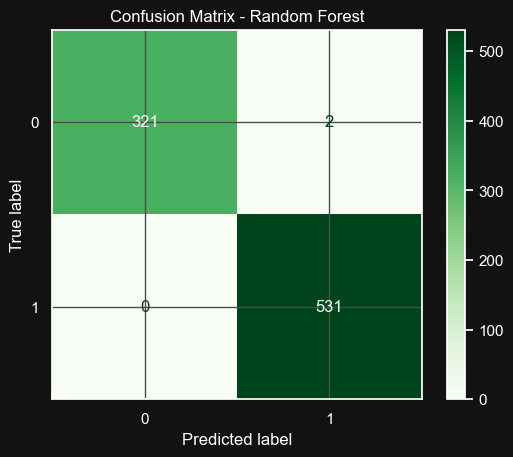

In [111]:
rf_cm = confusion_matrix(
    y_test,
    rf_test_pred
)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm
)

rf_disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")

plt.show()

#### Cross Validation

In [112]:
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCROSS VALIDATION")

print(f"CV Scores : {rf_cv_scores}")

print(
    f"Mean CV Accuracy : "
    f"{rf_cv_scores.mean():.4f}"
)


CROSS VALIDATION
CV Scores : [0.99882904 0.99648712 0.99882904 1.         1.        ]
Mean CV Accuracy : 0.9988


**Model Random Forest is overfiting**